In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Load the dataset from kaggle
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [2]:
#Perform EDA on the dataset
# Shape shows the number of rows and columns
df.shape
# Info shows attributes
df.info()
# isnull shows the number of null values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [3]:
# Describe calculates arithematic operations of each feature
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [4]:
# Show number of potability
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


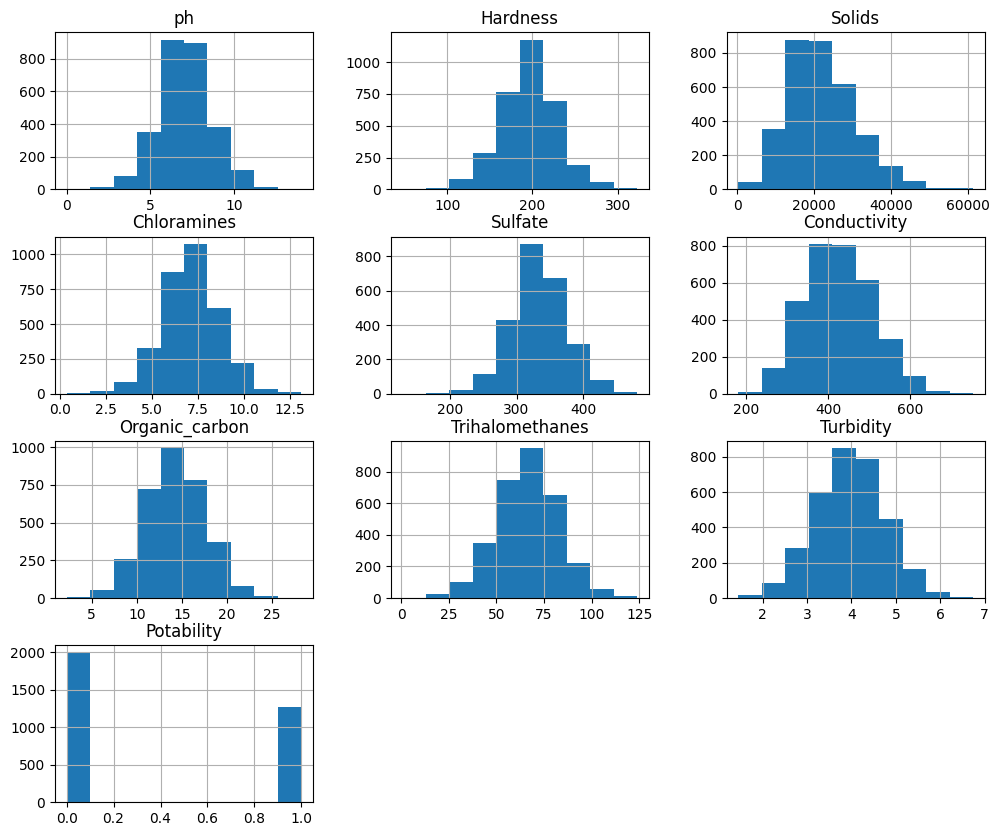

In [5]:
# each graph shows the spread of the values
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

In [6]:
#All the null values are filled with mean values
df = df.fillna(df.mean())
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [7]:
# new features are created to find the relationship between the chemicals
df['chemical_load'] = df['Sulfate'] + df['Chloramines']
df['mineral_density'] = df['Solids'] / df['Conductivity']
df['ph_hardness'] = df['ph'] * df['Hardness']

In [8]:
#Spilt the dataset
from sklearn.model_selection import train_test_split

X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#Fit the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
 10  chemical_load    3276 non-null   float64
 11  mineral_density  3276 non-null   float64
 12  ph_hardness      3276 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 332.8 KB


In [11]:
df.shape

(3276, 13)

In [12]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(3276, 12)
(2620, 12)
(656, 12)


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [14]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("Trained SVM")

Trained SVM


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    svm = SVC(kernel=k)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    print(f"SVM ({k}) Accuracy:", accuracy_score(y_test, y_pred))

SVM (linear) Accuracy: 0.6280487804878049
SVM (rbf) Accuracy: 0.6920731707317073
SVM (poly) Accuracy: 0.6387195121951219


In [16]:
from sklearn.metrics import classification_report

print("SVM Report:\n", classification_report(y_test, y_pred_svm))

SVM Report:
               precision    recall  f1-score   support

           0       0.69      0.91      0.79       412
           1       0.68      0.32      0.44       244

    accuracy                           0.69       656
   macro avg       0.69      0.62      0.61       656
weighted avg       0.69      0.69      0.66       656



In [17]:
#Check accuracy score
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Random Forest Accuracy: 0.6996951219512195
SVM Accuracy: 0.6920731707317073


In [18]:
from sklearn.metrics import confusion_matrix

print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

RF Confusion Matrix:
 [[373  39]
 [158  86]]
SVM Confusion Matrix:
 [[376  36]
 [166  78]]


In [21]:
import numpy as np

# Example input (same order as your features)
new_data = np.array([[7, 200, 15000, 7, 300, 400, 10, 70, 3,
                      307, 37.5, 1400]])  # include your engineered features also

# Scale input
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = svm.predict(new_data_scaled)

if prediction[0] == 1:
    print("Water is SAFE to drink ")
else:
    print("Water is NOT SAFE ")

Water is NOT SAFE 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
